# Group 2: Stock Factor Betas (Steps 1-5)

Estimate each stock's currency, AUD, market, and sector betas on stagger 2 by regressing
on one factor at a time and carrying the residuals forward. All data comes from group0's
`companies_and_staggered_returns.xlsx`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm

DATA_FILE = Path("../data/companies_and_staggered_returns.xlsx")
STAGGER = "stagger_2"


## Load the data

Get the stock list from the `Companies` sheet, and load stagger 2's time-weighted
returns and residual sector factors.

In [2]:
companies = pd.read_excel(DATA_FILE, sheet_name="Companies")

# Keep only real stocks: one row per ticker, and no ETF / FX / SPY rows
stocks = (
    companies
    .dropna(subset=["sector"])
    .drop_duplicates(subset=["ticker"])
    .reset_index(drop=True)
)

print(f"{len(stocks)} stocks")
print(f"Foreign stocks: {stocks.loc[stocks['currency'] != 'USD', 'ticker'].tolist()}")
stocks

43 stocks
Foreign stocks: ['VIST', 'STX', 'NTR', 'ASND', 'NOK']


,ticker,company_name,country,sector,currency
0,VST,Vistra Corp.,United States,Utilities,USD
1,VIST,"Vista Energy, S.A.B. de C.V.",Mexico,Energy,MXN
2,AEP,"American Electric Power Company, Inc.",United States,Utilities,USD
3,ETR,Entergy Corporation,United States,Utilities,USD
4,DIS,The Walt Disney Company,United States,Communication Services,USD
5,CMG,"Chipotle Mexican Grill, Inc.",United States,Consumer Discretionary,USD
6,AMZN,"Amazon.com, Inc.",United States,Consumer Discretionary,USD
7,FIX,"Comfort Systems USA, Inc.",United States,Industrials,USD
8,STX,Seagate Technology Holdings plc,Singapore,Technology,SGD
9,VLO,Valero Energy Corporation,United States,Energy,USD


In [3]:
returns = pd.read_excel(
    DATA_FILE, sheet_name=STAGGER, skiprows=254, nrows=80, parse_dates=["date"]
).set_index("date")
sector_factors = pd.read_excel(
    DATA_FILE, sheet_name=STAGGER, skiprows=338, nrows=80, parse_dates=["date"]
).set_index("date")

print(returns.shape)
returns.head()

(80, 61)


,VST,VIST,AEP,ETR,DIS,CMG,AMZN,FIX,STX,VLO,...,XLB,XLRE,XLK,XLU,MXN/USD,SGD/USD,CAD/USD,DKK/USD,EUR/USD,AUD/USD
date,,,,,,,,,,,,,,,,,,,,,
2020-07-27,-0.010961,0.063846,0.027994,0.044546,0.022594,0.048566,0.049309,0.118025,-0.024910,-0.001063,...,0.026109,0.009377,0.026018,0.026840,0.002653,0.007938,0.000174,0.025351,0.025030,0.021907
2020-08-24,0.018595,-0.089985,-0.052445,-0.028306,0.081393,0.065777,0.039842,0.017341,0.016576,-0.003605,...,0.032031,0.004694,0.060161,-0.016190,0.013116,0.007092,0.013256,0.006324,0.005959,0.005046
2020-09-21,-0.034672,-0.174135,0.016181,-0.011303,-0.049765,-0.025050,-0.052835,-0.008918,0.026700,-0.124691,...,-0.010732,-0.026482,-0.042279,0.001466,-0.015061,-0.007518,-0.012321,-0.013217,-0.013067,-0.016609
2020-10-19,0.038649,0.002584,0.073941,0.066012,0.019556,0.041546,0.019679,0.050786,0.028893,-0.025759,...,0.031268,0.015492,0.021970,0.055445,0.038954,0.007224,0.011094,0.011394,0.011153,0.005514
2020-11-16,-0.033161,0.059561,-0.057314,0.005187,0.054358,-0.020335,-0.019165,-0.063692,0.052720,0.120281,...,0.031872,0.020770,0.008054,-0.010852,0.021316,0.006049,0.001317,-0.000735,-0.000345,0.011429


In [4]:
# Map each GICS sector to its SPDR sector ETF (the residual factor columns
# in group0's file are named like 'XLB_residual')
sector_to_etf = {
    "Communication Services": "XLC",
    "Consumer Discretionary": "XLY",
    "Consumer Staples": "XLP",
    "Energy": "XLE",
    "Financials": "XLF",
    "Health Care": "XLV",
    "Industrials": "XLI",
    "Materials": "XLB",
    "Real Estate": "XLRE",
    "Technology": "XLK",
    "Utilities": "XLU",
}

# The FX return columns are named like 'MXN/USD', so a stock's currency code
# tells us which column to use
def fx_column(currency):
    return currency + "/USD"


## The regression helper

Every step is the same OLS regression with an intercept; the residual carried to the
next step is `return - (alpha + beta * factor)`, same as group0.

In [5]:
def regress(y, x):
    """Regress y on x (with an intercept). Return beta, alpha, and beta's t-stat."""
    X = sm.add_constant(x)
    model = sm.OLS(y, X, missing="drop").fit()
    beta = model.params.iloc[1]
    alpha = model.params.iloc[0]
    t_stat = model.tvalues.iloc[1]
    return beta, alpha, t_stat

## Steps 1-5: the stepwise regressions

For each stock: (1) foreign stocks regress on their local currency and keep the beta
(US stocks skip this); (2) regress the residuals on AUD and keep the beta only if
|t| > 2, otherwise set it to 0; (3) regress on SPY, keep the beta; (4) regress on the
stock's own residual sector factor, keep the beta. What's left is the stock-specific return.

In [6]:
beta_rows = []
stock_specific = pd.DataFrame(index=returns.index)

for _, stock in stocks.iterrows():
    ticker = stock["ticker"]
    r = returns[ticker].astype(float)

    # Step 1: own local currency (prior, keep the beta)
    if stock["currency"] != "USD":
        fx = returns[fx_column(stock["currency"])].astype(float)
        beta_fx, alpha, _ = regress(r, fx)
        r = r - (alpha + beta_fx * fx)
    else:
        beta_fx = 0.0   # US stocks skip this step

    # Steps 2-3: AUD (not a prior, must pass |t| > 2)
    aud = returns["AUD/USD"].astype(float)
    beta_aud, alpha, t_aud = regress(r, aud)
    if abs(t_aud) > 2:
        r = r - (alpha + beta_aud * aud)
    else:
        beta_aud = 0.0  # insignificant -> beta set to zero, returns unchanged

    # Step 4: market (prior, keep the beta)
    spy = returns["SPY"].astype(float)
    beta_mkt, alpha, _ = regress(r, spy)
    r = r - (alpha + beta_mkt * spy)

    # Step 5: own residual sector factor (prior, keep the beta)
    etf = sector_to_etf[stock["sector"]]
    sector = sector_factors[etf + "_residual"].astype(float)
    beta_sector, alpha, _ = regress(r, sector)
    r = r - (alpha + beta_sector * sector)

    # r is now the stock-specific return
    stock_specific[ticker] = r
    beta_rows.append({
        "ticker": ticker,
        "sector": stock["sector"],
        "currency": stock["currency"],
        "beta_fx": beta_fx,
        "beta_aud": beta_aud,
        "aud_t_stat": t_aud,
        "beta_mkt": beta_mkt,
        "beta_sector": beta_sector,
        "residual_risk": r.std(),
    })

betas = pd.DataFrame(beta_rows)
print(f"{len(betas)} betas estimated on {STAGGER}")
print("AUD beta kept (|t| > 2):", f"{(betas['beta_aud'] != 0).sum()} of {len(betas)}")
betas.round(3)

43 betas estimated on stagger_2
AUD beta kept (|t| > 2): 33 of 43


,ticker,sector,currency,beta_fx,beta_aud,aud_t_stat,beta_mkt,beta_sector,residual_risk
0,VST,Utilities,USD,0.000,0.000,1.041,1.088,0.938,0.116
1,VIST,Energy,MXN,0.766,1.058,2.021,-0.027,0.835,0.112
2,AEP,Utilities,USD,0.000,0.000,0.679,-0.066,1.094,0.030
3,ETR,Utilities,USD,0.000,0.000,0.605,0.112,0.966,0.034
4,DIS,Communication Services,USD,0.000,1.183,3.513,0.762,0.614,0.070
5,CMG,Consumer Discretionary,USD,0.000,0.000,1.584,0.749,1.064,0.091
6,AMZN,Consumer Discretionary,USD,0.000,1.438,3.690,1.042,1.230,0.070
7,FIX,Industrials,USD,0.000,1.987,4.097,0.767,1.204,0.103
8,STX,Technology,SGD,4.057,1.674,2.644,1.137,2.202,0.127
9,VLO,Energy,USD,0.000,1.227,2.958,0.260,1.115,0.066


## Verification 1: orthogonality

The stock-specific returns should be uncorrelated with the removed factors: sector is
exactly 0, SPY is ~0, but the foreign stocks regain some local-currency correlation
because the later AUD/SPY steps subtract components that co-move with those currencies.

In [7]:
checks = []
for _, stock in stocks.iterrows():
    ticker = stock["ticker"]
    r = stock_specific[ticker]
    etf = sector_to_etf[stock["sector"]]
    row = {
        "ticker": ticker,
        "corr_spy": r.corr(returns["SPY"]),
        "corr_sector": r.corr(sector_factors[etf + "_residual"]),
    }
    # only meaningful where the factor was actually removed
    if stock["currency"] != "USD":
        row["corr_fx"] = r.corr(returns[fx_column(stock["currency"])])
    checks.append(row)

checks = pd.DataFrame(checks)
print("Largest correlation (absolute value) between the stock-specific returns")
print("and each removed factor:")
checks[["corr_spy", "corr_sector", "corr_fx"]].abs().max().round(6)

Largest correlation (absolute value) between the stock-specific returns
and each removed factor:


corr_spy       0.001810
corr_sector    0.000000
corr_fx        0.350508
dtype: float64

## Verification 2: a visual example

One stock's returns vs SPY before the regressions, and its stock-specific returns after
(no market relationship left).

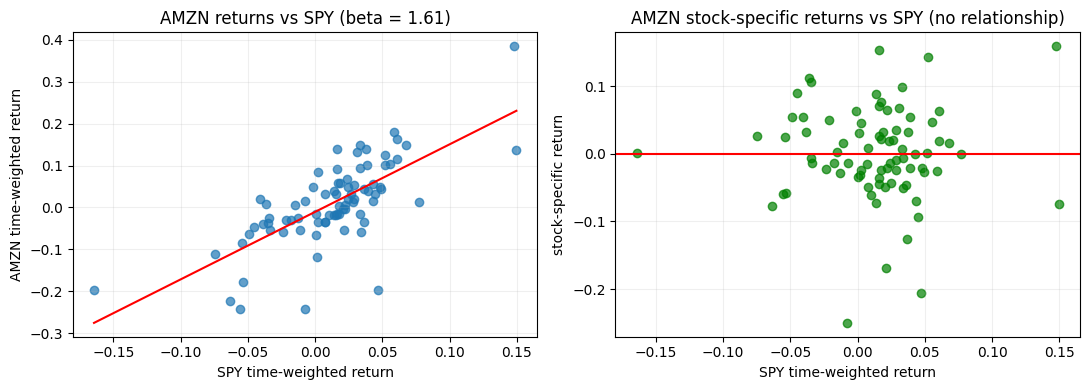

In [8]:
import matplotlib.pyplot as plt

EXAMPLE = "AMZN"

raw = returns[EXAMPLE].astype(float)
spy = returns["SPY"].astype(float)
final = stock_specific[EXAMPLE]

beta_raw, alpha_raw, _ = regress(raw, spy)
line_x = np.linspace(spy.min(), spy.max(), 100)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(spy, raw, alpha=0.7)
axes[0].plot(line_x, alpha_raw + beta_raw * line_x, color="red")
axes[0].set_title(f"{EXAMPLE} returns vs SPY (beta = {beta_raw:.2f})")
axes[0].set_xlabel("SPY time-weighted return")
axes[0].set_ylabel(f"{EXAMPLE} time-weighted return")
axes[0].grid(alpha=0.2)

axes[1].scatter(spy, final, alpha=0.7, color="green")
axes[1].axhline(0, color="red")
axes[1].set_title(f"{EXAMPLE} stock-specific returns vs SPY (no relationship)")
axes[1].set_xlabel("SPY time-weighted return")
axes[1].set_ylabel("stock-specific return")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Save the results

Write the stagger 2 betas and the stock-specific returns to one Excel file.

In [9]:
output_file = Path("group2_stock_betas.xlsx")

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    betas.to_excel(writer, sheet_name="Betas", index=False)
    (stock_specific
     .rename_axis("date")
     .reset_index()
     .to_excel(writer, sheet_name="Residuals", index=False))

print(f"saved {output_file.resolve().name}")

saved group2_stock_betas.xlsx
